# WORK IN PROGRESS

# Final Project

#### Title: Machine Learning for Obesity Level Prediction and Lifesytle Pattern Discovery
#### Class: AAI 501-02 - Introduction to Artificial Intelligence
#### Team 4: Dina Othman, Erika Gallegos, Hassaan Abbasi

In [1]:
pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [24]:
## libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
import os
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid", context="notebook")


In [11]:
 # Importing the data (.CSV file) from the local folder

data_path = "ObesityDataSet_raw_and_data_sinthetic.csv"  # put the file is in same folder as notebook

print("Working directory:", os.getcwd())
print("Loading:", data_path)

df = pd.read_csv(data_path)

df.head()


Working directory: /Users/hassaanabbasi/Downloads/ProjectAAI-501-ObseityLevel-
Loading: ObesityDataSet_raw_and_data_sinthetic.csv


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


Basic Data Cleaning

In [22]:
#  basic cleaning

# 1) Drop exact duplicate rows
df_clean = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df_clean.shape)

# 2) No missing values in this dataset, 
missing_counts = df_clean.isna().sum()
print("Missing values per column after cleaning:")
print(missing_counts)

# 3) Verify dtypes
print("\nData types:")
print(df_clean.dtypes)


Shape after dropping duplicates: (2087, 17)
Missing values per column after cleaning:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Data types:
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                    

EDA: distributions, correlations, key lifestyle variables
Keeping the EDA on unencoded data so plots are interpretable.

In [21]:
#  column groups

target_col = "NObeyesdad"

categorical_cols = ["Gender","family_history_with_overweight","FAVC","CAEC","SMOKE","SCC","CALC","MTRANS",
    target_col,  # keep target in its own group when needed
]

numeric_cols = ["Age","Height","Weight","FCVC", "NCP","CH2O","FAF", "TUE",]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Categorical columns: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']


Summary of Statisitcs After cleaning and EDA-Distruibution

In [20]:
print("Numeric summary:")
display(df_clean[numeric_cols].describe())

print("\nCategorical summary (value counts):")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_clean[col].value_counts())

Numeric summary:


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730,2.421466,2.701179,2.004749,1.012812,0.663035
std,6.368801,0.093186,26.190847,0.534737,0.764614,0.608284,0.853475,0.608153
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.915937,1.630178,66.000000,2.000000,2.697467,1.590922,0.124505,0.000000
50%,22.847618,1.701584,83.101100,2.396265,3.000000,2.000000,1.000000,0.630866
75%,26.000000,1.769491,108.015907,3.000000,3.000000,2.466193,1.678102,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Categorical summary (value counts):

--- Gender ---
Gender
Male      1052
Female    1035
Name: count, dtype: int64

--- family_history_with_overweight ---
family_history_with_overweight
yes    1722
no      365
Name: count, dtype: int64

--- FAVC ---
FAVC
yes    1844
no      243
Name: count, dtype: int64

--- CAEC ---
CAEC
Sometimes     1761
Frequently     236
Always          53
no              37
Name: count, dtype: int64

--- SMOKE ---
SMOKE
no     2043
yes      44
Name: count, dtype: int64

--- SCC ---
SCC
no     1991
yes      96
Name: count, dtype: int64

--- CALC ---
CALC
Sometimes     1380
no             636
Frequently      70
Always           1
Name: count, dtype: int64

--- MTRANS ---
MTRANS
Public_Transportation    1558
Automobile                456
Walking                    55
Motorbike                  11
Bike                        7
Name: count, dtype: int64

--- NObeyesdad ---
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Ove

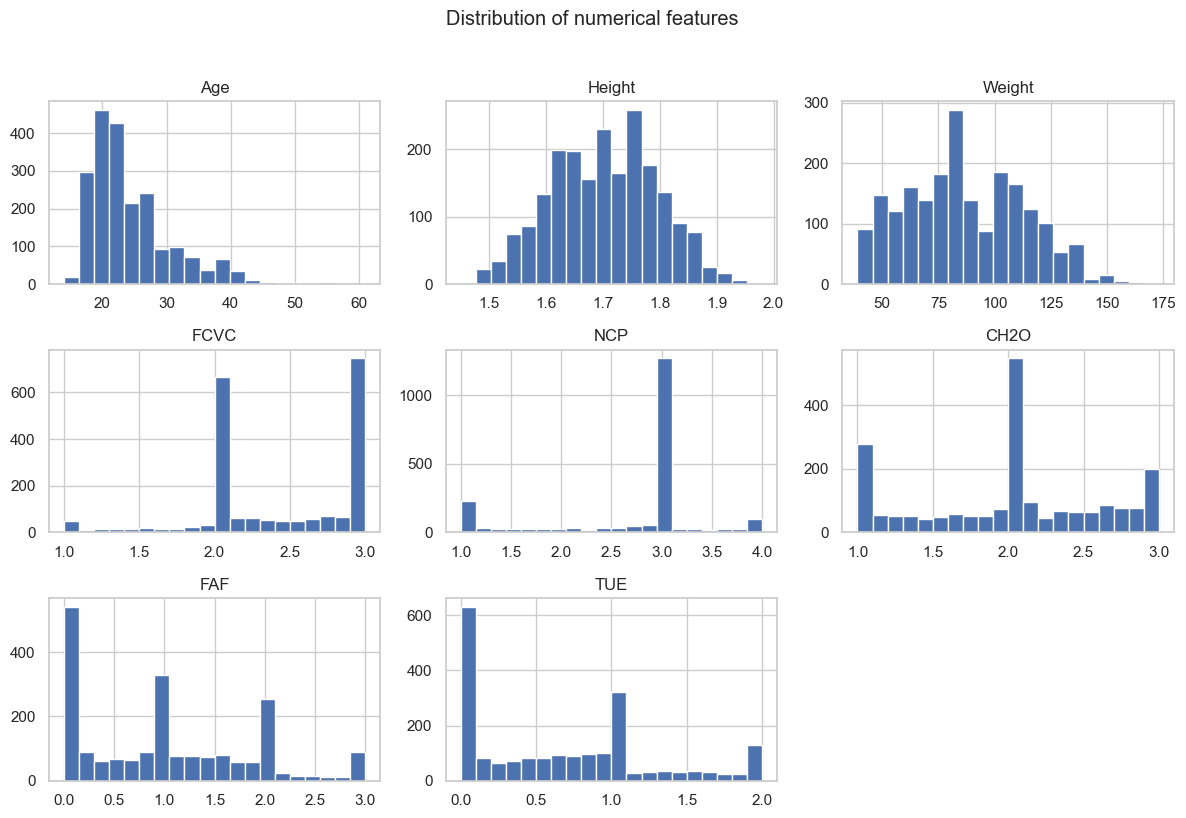

In [19]:
# histograms for numeric features
df_clean[numeric_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Distribution of numerical features", y=1.02)
plt.tight_layout()
plt.show()


Targer Distribution

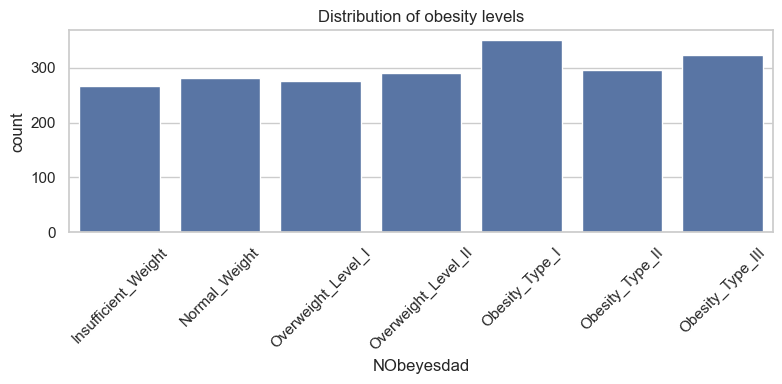

In [ ]:
# target distribution

obesity_order = ["Insufficient_Weight","Normal_Weight", "Overweight_Level_I","Overweight_Level_II","Obesity_Type_I","Obesity_Type_II","Obesity_Type_III",]

plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean,x=target_col,order=obesity_order,)
plt.xticks(rotation=45)
plt.title("Distribution of obesity levels")
plt.tight_layout()
plt.show()


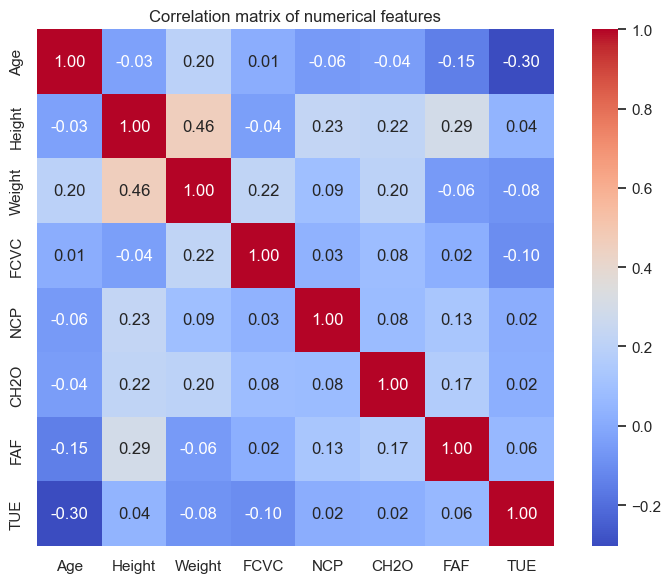

In [16]:
# correlation matrix

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation matrix of numerical features")
plt.tight_layout()
plt.show()


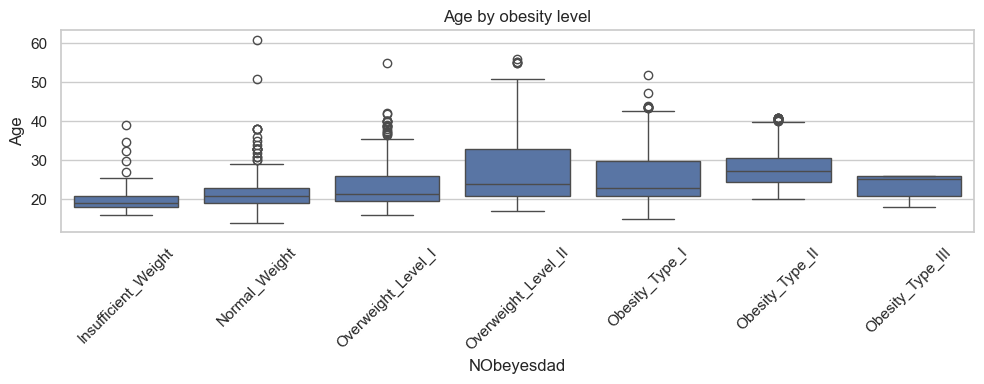

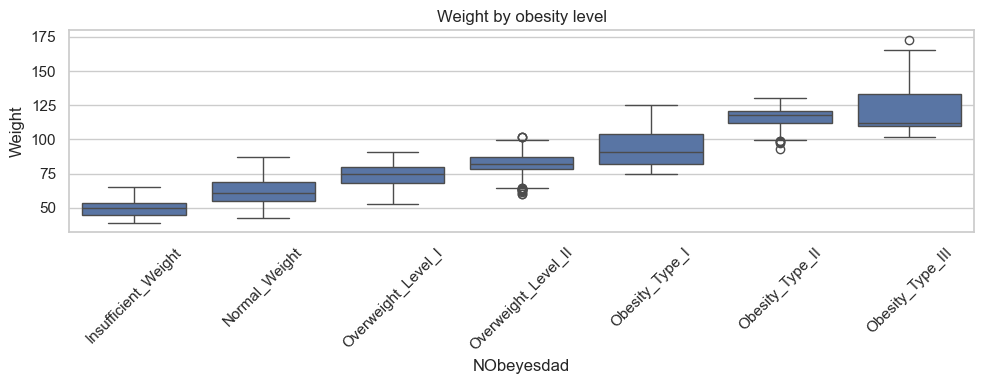

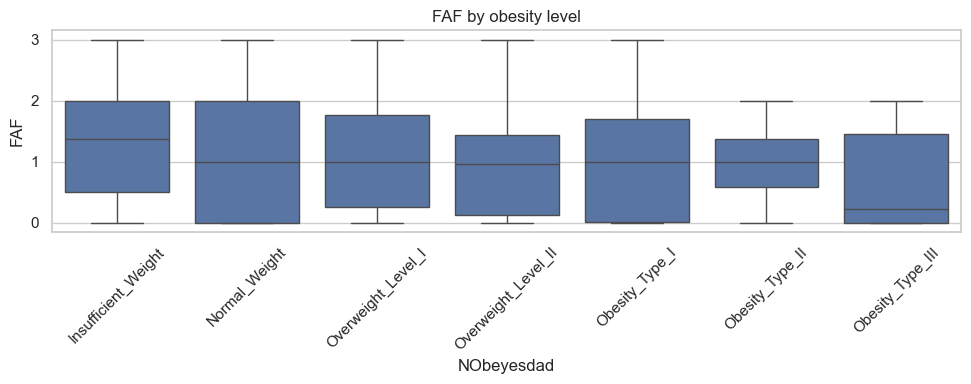

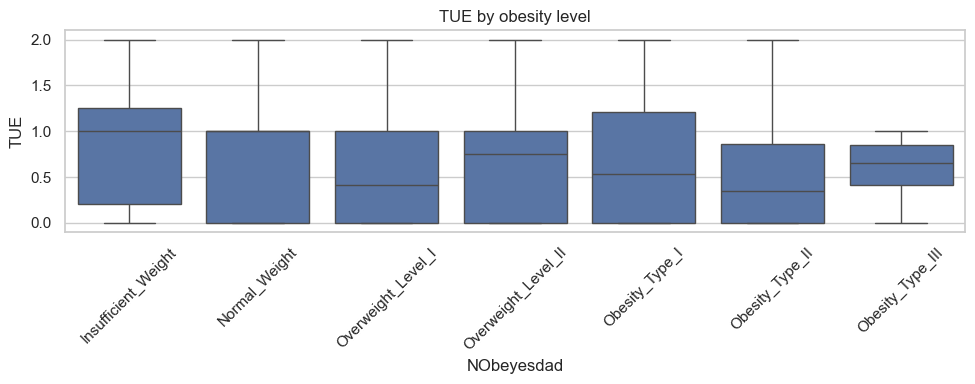

In [25]:
# numeric and obesity level difference

for col in ["Age", "Weight", "FAF", "TUE"]:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df_clean,x=target_col,y=col,order=obesity_order,)
    plt.xticks(rotation=45)
    plt.title(f"{col} by obesity level")
    plt.tight_layout()
    plt.show()


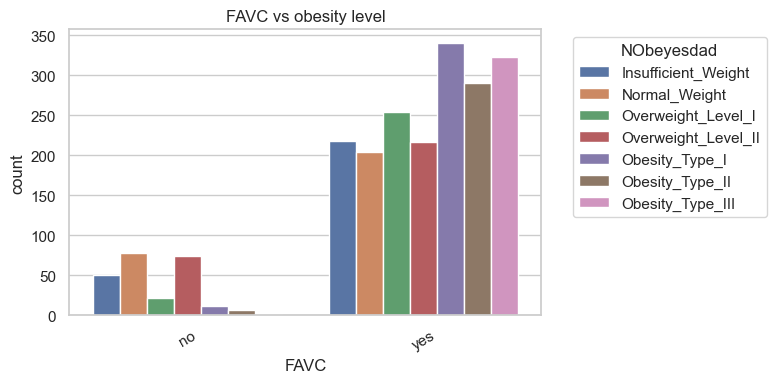

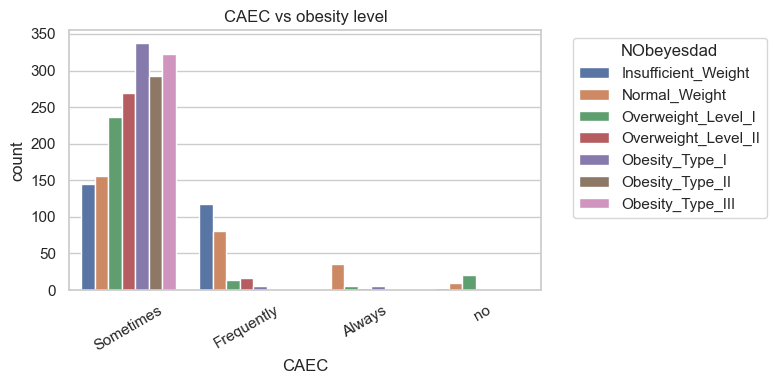

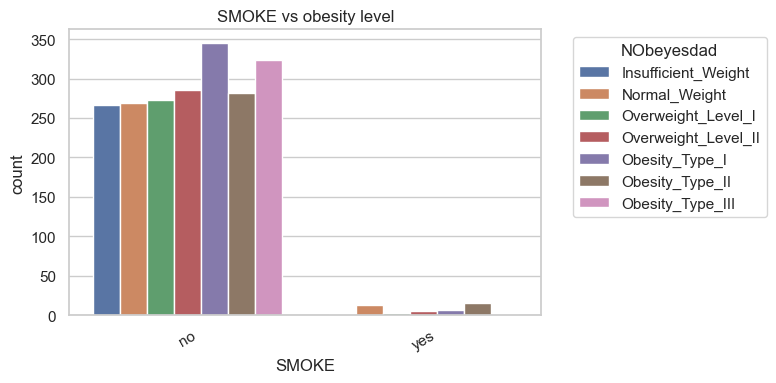

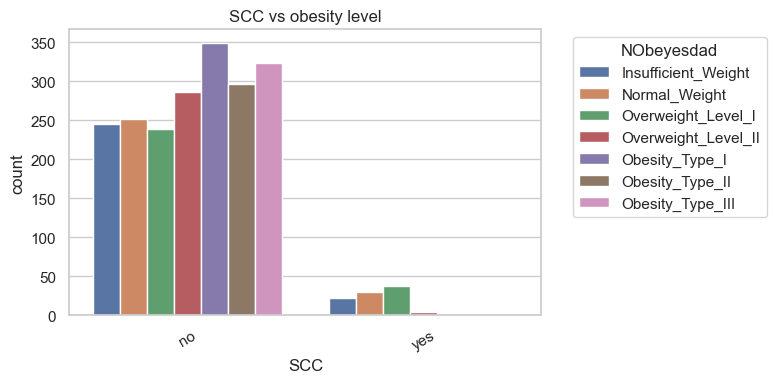

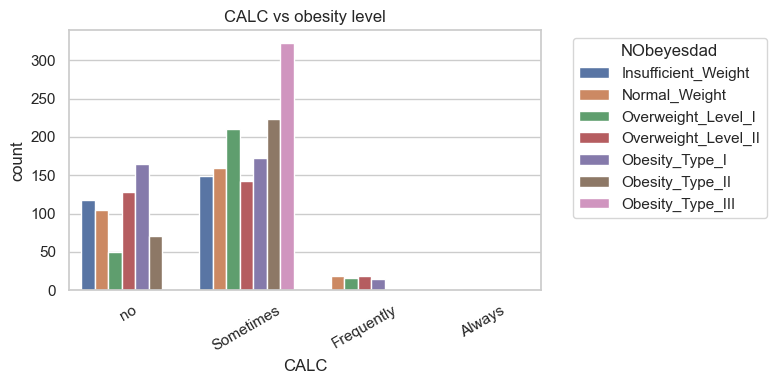

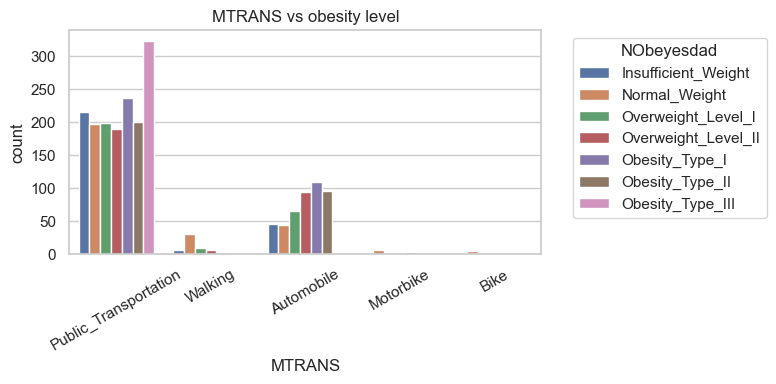

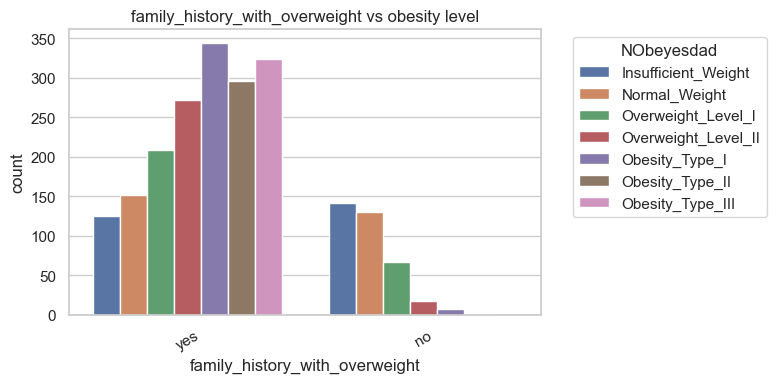

In [ ]:
#  helper function for lifestyle categorical variables vs obesity

def plot_cat_vs_obesity(df, cat_col, target_col="NObeyesdad", order=None):
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df,x=cat_col, hue=target_col,hue_order=obesity_order,order=order,)
    plt.xticks(rotation=30)
    plt.title(f"{cat_col} vs obesity level")
    plt.legend(title=target_col, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()



    # lifestyle variables vs obesity level
    # Got a help from chatgpt, to help me plot it nicely with different colors
    
plot_cat_vs_obesity(df_clean, "FAVC", target_col)   # high-calorie food
plot_cat_vs_obesity(df_clean, "CAEC", target_col)   # eating between meals
plot_cat_vs_obesity(df_clean, "SMOKE", target_col)
plot_cat_vs_obesity(df_clean, "SCC", target_col)    # calorie monitoring
plot_cat_vs_obesity(df_clean, "CALC", target_col)   # alcohol
plot_cat_vs_obesity(df_clean, "MTRANS", target_col) # transportation mode
plot_cat_vs_obesity(df_clean, "family_history_with_overweight", target_col)



In [ ]:
# encode categorical features (excluding target)

feature_cat_cols = ["Gender","family_history_with_overweight", "FAVC", "CAEC","SMOKE", "SCC","CALC", "MTRANS",]

X = df_clean.drop(columns=[target_col])  
y = df_clean[target_col].copy()          # target

X_encoded = pd.get_dummies(X,columns=feature_cat_cols,
    drop_first=True,   # avoid dummy variable 
)

print("Shape after encoding:", X_encoded.shape)
X_encoded.head()




Shape after encoding: (2087, 23)


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,False,True,...,False,False,False,False,False,True,False,False,True,False
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,False,True,...,False,True,True,False,True,False,False,False,True,False
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,True,True,...,False,False,False,True,False,False,False,False,True,False
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,True,False,...,False,False,False,True,False,False,False,False,False,True
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,True,False,...,False,False,False,False,True,False,False,False,True,False


In [34]:
# scale numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# numeric columns are unchanged by encoding, so we can reuse the list
X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])
X_encoded[numeric_cols].head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
0,-0.526613,-0.887408,-0.872985,-0.788364,0.390906,-0.007810,-1.186977,0.554211
1,-0.526613,-1.960788,-1.178508,1.082164,0.390906,1.636552,2.328908,-1.090505
2,-0.212507,1.044677,-0.376509,-0.788364,0.390906,-0.007810,1.156947,0.554211
3,0.415705,1.044677,0.005395,1.082164,0.390906,-0.007810,1.156947,-1.090505
4,-0.369560,0.830001,0.112328,-0.788364,-2.225418,-0.007810,-1.186977,-1.090505


## Data

In [2]:
from ucimlrepo import fetch_ucirepo

## get data
df = fetch_ucirepo(id = 544)

## Supervised Machine Learning

### Logistic Regression

Predicting obesity level (NObeyesdad).

Values:  
Obesity_Type_I  
Obesity_Type_III  
Obesity_Type_II  
Overweight_Level_I  
Overweight_Level_II  
Normal_Weight  
Insufficient_Weight  

In [9]:
## format data
x = df.data.features
y = df.data.targets

In [24]:
## identify column types
categorical_cols = x.select_dtypes(include = ['object', 'category']).columns.tolist()
numeric_cols = x.select_dtypes(include = ['int64', 'float64']).columns.tolist()

In [23]:
## split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 33, stratify = y)

In [26]:
## scale numerical variables, dummy level categoricals

# training data
ohe = OneHotEncoder(drop = 'first', sparse_output = False)
x_train_cat = ohe.fit_transform(x_train[categorical_cols])
x_test_cat = ohe.transform(x_test[categorical_cols])

# test data
scaler = StandardScaler()
x_train_num = scaler.fit_transform(x_train[numeric_cols])
x_test_num = scaler.transform(x_test[numeric_cols])

In [27]:
## recombine transformed variables

# training data
x_train_processed = np.hstack([x_train_num, x_train_cat])

# test data
x_test_processed = np.hstack([x_test_num, x_test_cat])

In [28]:
## train model
model = LogisticRegression()
model.fit(x_train_processed, y_train)

LogisticRegression()

In [34]:
## evaluate model performance on test data
y_pred = model.predict(x_test_processed)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names = df.target_names))

Accuracy: 0.8817966903073287

Confusion Matrix:
 [[52  2  0  0  0  0  0]
 [10 43  0  0  0  3  2]
 [ 0  0 61  3  1  0  5]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  0 65  0  0]
 [ 0  5  0  0  0 45  8]
 [ 0  0  4  0  0  7 47]]

Classification Report:
                      precision    recall  f1-score   support

Insufficient_Weight       0.84      0.96      0.90        54
      Normal_Weight       0.86      0.74      0.80        58
     Obesity_Type_I       0.94      0.87      0.90        70
    Obesity_Type_II       0.95      1.00      0.98        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.82      0.78      0.80        58
Overweight_Level_II       0.76      0.81      0.78        58

           accuracy                           0.88       423
          macro avg       0.88      0.88      0.88       423
       weighted avg       0.88      0.88      0.88       423



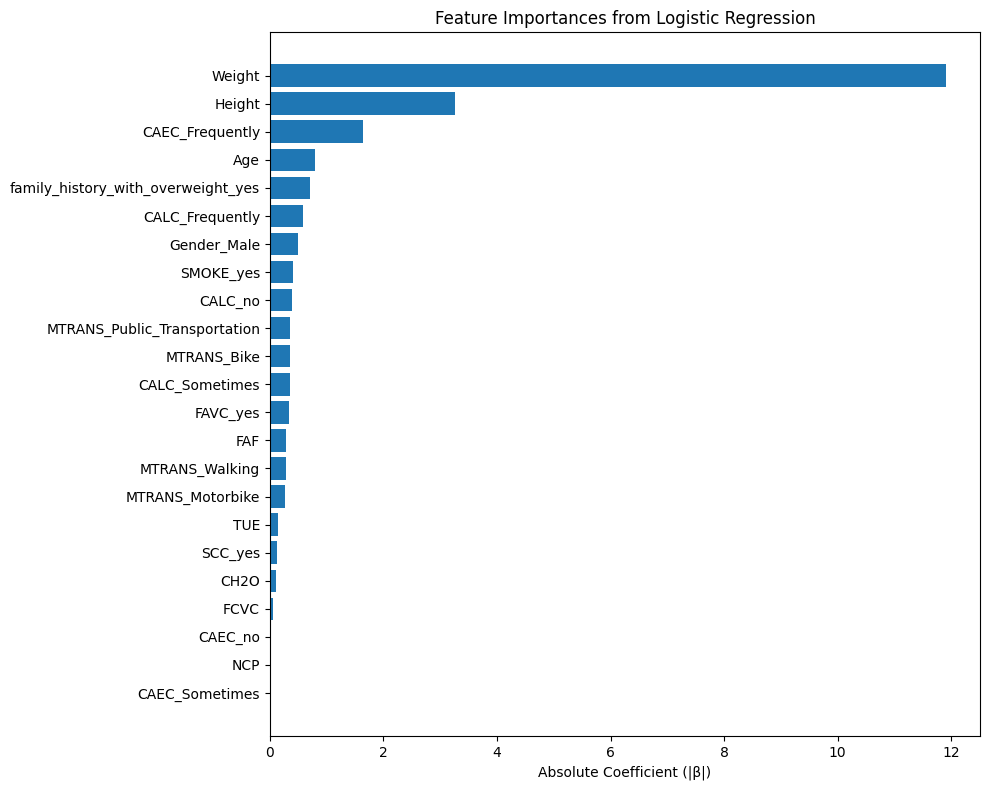

In [39]:
## plot feature importance

# get categorical feature names
encoded_cat_names = ohe.get_feature_names_out(categorical_cols)

# get numeric feature names and append categorical
all_feature_names = numeric_cols + list(encoded_cat_names)

# logistic regression coefficients
coefs = model.coef_[0]

# get feature importance values
feature_importances = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': coefs,
    'importance': np.abs(coefs)
}).sort_values('importance', ascending = False)

feature_importances.head()

# create plot
plt.figure(figsize = (6, 6))
plt.barh(feature_importances['feature'], feature_importances['importance'])
plt.xlabel('Absolute Coefficient (|β|)')
plt.title('Feature Importances from Logistic Regression')
plt.gca().invert_yaxis()  # largest at top
plt.tight_layout()
plt.show()

### Random Forest

In [42]:
## base model
rf = RandomForestClassifier(
    n_estimators = 500,
    max_depth = None,
    min_samples_split = 2,
    min_samples_leaf = 1,
    random_state = 33,
    n_jobs = -1
)

## train model
rf.fit(x_train_processed, y_train)


RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [43]:
## evaluate model performance
y_pred_rf = rf.predict(x_test_processed)

print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_rf))
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9527186761229315

Confusion Matrix:
 [[50  4  0  0  0  0  0]
 [ 1 56  0  0  0  1  0]
 [ 0  0 69  1  0  0  0]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  0 65  0  0]
 [ 0  8  0  0  0 49  1]
 [ 0  4  0  0  0  0 54]]

Classification Report:
                      precision    recall  f1-score   support

Insufficient_Weight       0.98      0.93      0.95        54
      Normal_Weight       0.78      0.97      0.86        58
     Obesity_Type_I       1.00      0.99      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.98      0.84      0.91        58
Overweight_Level_II       0.98      0.93      0.96        58

           accuracy                           0.95       423
          macro avg       0.96      0.95      0.95       423
       weighted avg       0.96      0.95      0.95       423



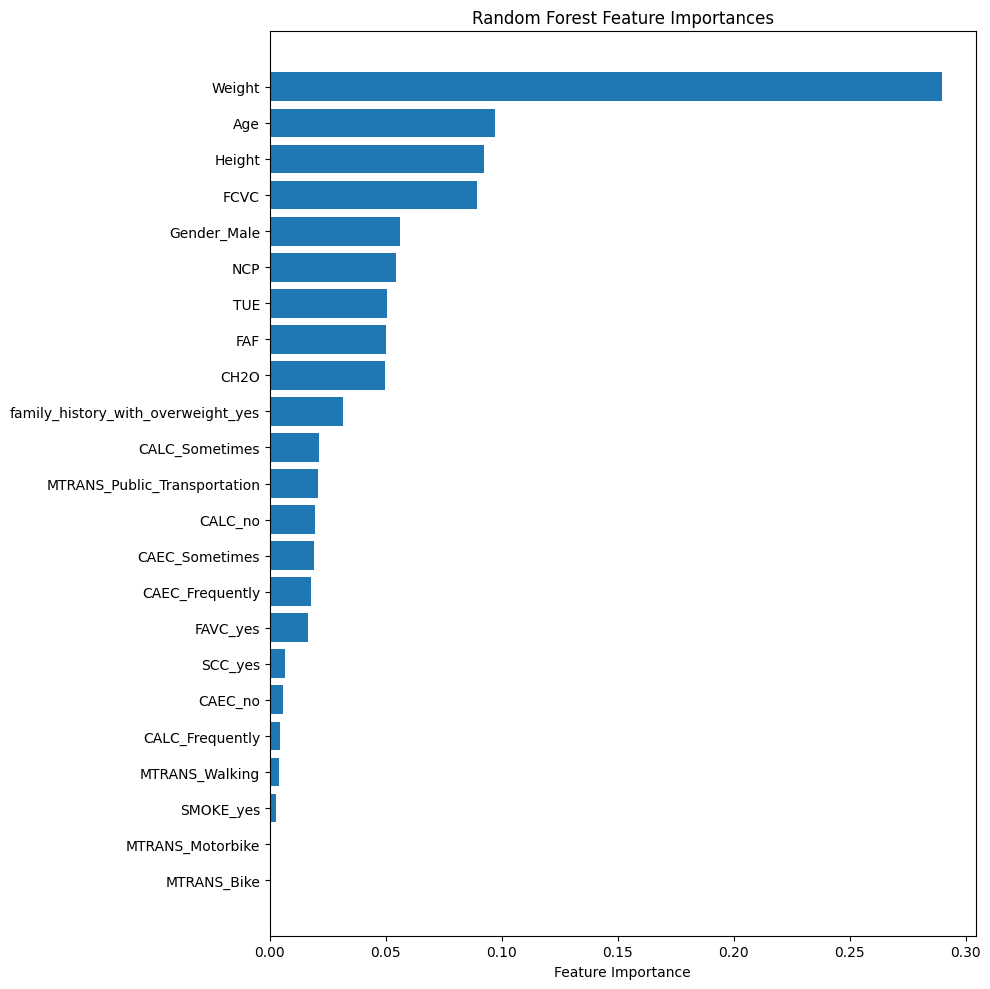

In [45]:
## create feature importance plot

importances = rf.feature_importances_

rf_imp = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending = False)

# plot
plt.figure(figsize=(6, 6))
plt.barh(rf_imp['feature'], rf_imp['importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [49]:
## tune model
rf = RandomForestClassifier(random_state = 42)

param_dist = {
    "n_estimators": randint(100, 400),
    "max_depth": [10, 20, 30, None],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=40,                # try 40 combinations
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(x_train_processed, y_train)

print("Best Score from Randomized Search:", random_search.best_score_)
print("Best Params from Randomized Search:\n", random_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


KeyboardInterrupt: 

In [ ]:
## evaluate model performance

best_rf = random_search.best_estimator_

y_pred = best_rf.predict(x_test_processed)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [ ]:
# Get feature importances from the best model
importances = best_rf.feature_importances_

# Build a dataframe
rf_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

# Plot all importances
plt.figure(figsize=(10, 12))
plt.barh(rf_imp["feature"], rf_imp["importance"])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances (Tuned RF)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
